# Image Captioning + GenZ/Brainrot Rewriter

1. Loads a **small slice** of COCO captions
2. Trains a real attention-based encoder-decoder captioning model (InceptionResNetV2 + GRU)
3. Demo: **uploaded image**
4. Rewrites the caption in **GenZ/brainrot style**

## 0. Install & imports

In [1]:
!pip -q install tensorflow tensorflow-datasets keras pillow

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import re
import random
import numpy as np
import matplotlib.pyplot as plt
from textwrap import wrap
from PIL import Image

import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import Input
from keras.layers import (
    GRU, Add, Attention, Dense, Embedding,
    LayerNormalization, Rescaling, Reshape, Resizing,
    StringLookup, TextVectorization,
)

print("TF:", tf.__version__, "| Keras:", keras.__version__)

TF: 2.19.0 | Keras: 3.13.2


## 1. Config

In [3]:
# Dataset
GCS_DIR        = "gs://asl-public-data/data/tensorflow_datasets/"
DATASET_SLICE  = "train[:10%]"
BUFFER_SIZE    = 500
BATCH_SIZE     = 32

# Image
IMG_HEIGHT   = 299
IMG_WIDTH    = 299
IMG_CHANNELS = 3

# Model
VOCAB_SIZE        = 5000
ATTENTION_DIM     = 512
WORD_EMBEDDING_DIM = 128
MAX_CAPTION_LEN   = 40
FEATURES_SHAPE    = (8, 8, 1536)  # InceptionResNetV2 spatial output

# Training
EPOCHS = 15

print("Config ready")

Config ready


## 2. Load and preprocess

In [4]:
resize  = Resizing(IMG_HEIGHT, IMG_WIDTH)
rescale = Rescaling(1.0 / 255)

def get_image_label(example):
    # Resize + normalise image; grab first caption only
    caption = example["captions"]["text"][0]
    img = resize(example["image"])
    img = rescale(img)
    return {"image_tensor": img, "caption": caption}

def add_start_end_token(data):
    start = keras.ops.convert_to_tensor("<start>")
    end   = keras.ops.convert_to_tensor("<end>")
    data["caption"] = tf.strings.join([start, data["caption"], end], separator=" ")
    return data

print(f"Loading '{DATASET_SLICE}' slice from GCS..")
raw_ds = tfds.load("coco_captions", split=DATASET_SLICE, data_dir=GCS_DIR)

trainds = (
    raw_ds
    .map(get_image_label,     num_parallel_calls=tf.data.AUTOTUNE)
    .map(add_start_end_token, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Dataset pipeline ready")

Loading 'train[:10%]' slice from GCS..
Dataset pipeline ready


### 2a. Check data

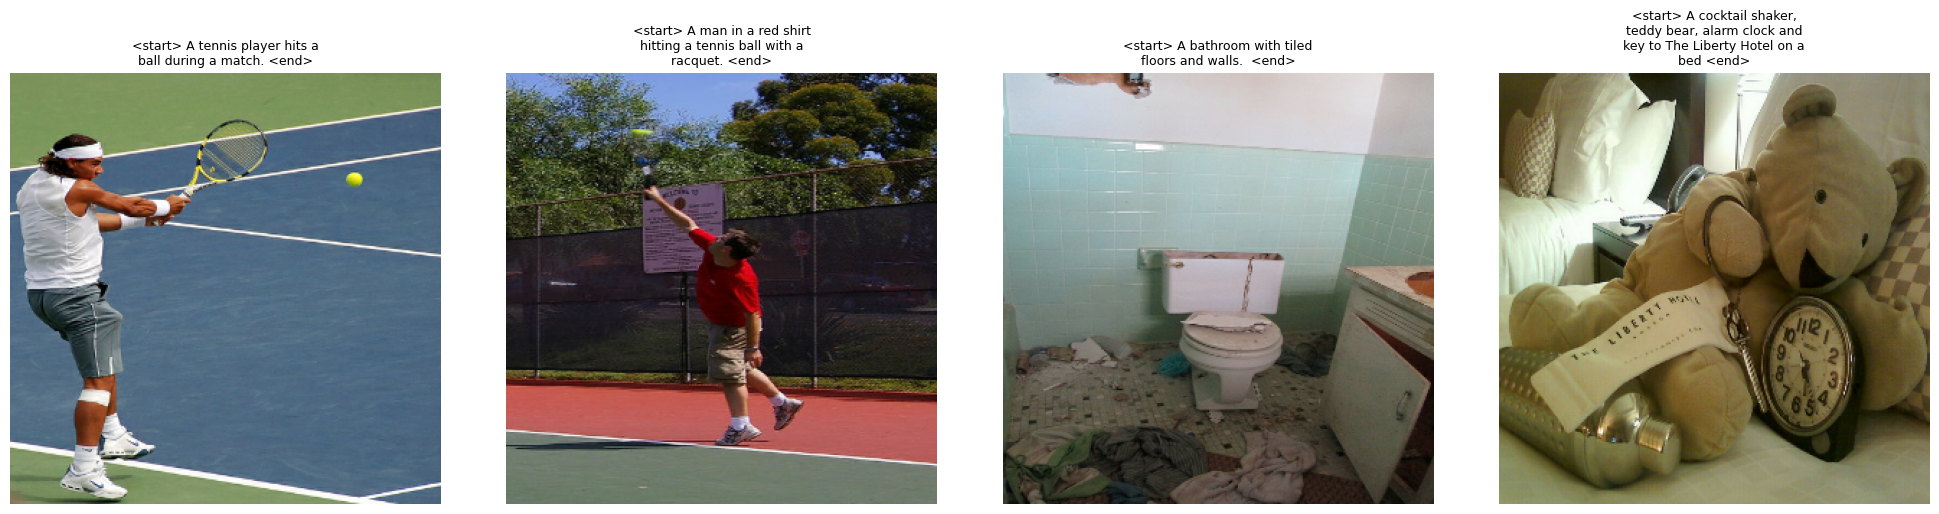

In [5]:
f, ax = plt.subplots(1, 4, figsize=(20, 5))
for idx, data in enumerate(trainds.take(4)):
    ax[idx].imshow(data["image_tensor"].numpy())
    cap = "\n".join(wrap(data["caption"].numpy().decode("utf-8"), 30))
    ax[idx].set_title(cap, fontsize=9)
    ax[idx].axis("off")
plt.tight_layout()
plt.show()

## 3. Tokenise captions

In [6]:
def standardize(inputs):
    inputs = tf.strings.lower(inputs)
    return tf.strings.regex_replace(
        inputs, r'[!"#$%&\(\)\*\+.,-/:;=?@\[\\\]^_`{|}~]?', ""
    )

tokenizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize=standardize,
    output_sequence_length=MAX_CAPTION_LEN,
)

print("Adapting tokenizer..")
tokenizer.adapt(trainds.map(lambda x: x["caption"]))

word_to_index = StringLookup(mask_token="", vocabulary=tokenizer.get_vocabulary())
index_to_word = StringLookup(mask_token="", vocabulary=tokenizer.get_vocabulary(), invert=True)

print(f"Vocabulary size: {len(tokenizer.get_vocabulary())} words")

Adapting tokenizer..
Vocabulary size: 4297 words


## 4. Build batched training dataset

In [7]:
def create_ds_fn(data):
    img_tensor = data["image_tensor"]
    caption    = tokenizer(data["caption"])
    # Label = caption shifted left by one position (next-word prediction)
    target  = keras.ops.roll(caption, -1, 0)
    zeros   = keras.ops.zeros([1], dtype="int32")
    target  = keras.ops.concatenate((target[:-1], zeros), axis=-1)
    return (img_tensor, caption), target

batched_ds = (
    trainds
    .map(create_ds_fn)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

for (img, cap), lbl in batched_ds.take(1):
    print(f"Image batch:   {img.shape}")
    print(f"Caption batch: {cap.shape}")
    print(f"Label batch:   {lbl.shape}")
print("Batched dataset ready")

Image batch:   (32, 299, 299, 3)
Caption batch: (32, 40)
Label batch:   (32, 40)
Batched dataset ready


## 5. Build the model

Architecture: **InceptionResNetV2 encoder** (frozen ImageNet weights) -> **GRU decoder with Luong-style attention**

In [8]:
print("Loading InceptionResNetV2 weights (ImageNet)...")
FEATURE_EXTRACTOR = keras.applications.inception_resnet_v2.InceptionResNetV2(
    include_top=False, weights="imagenet"
)
FEATURE_EXTRACTOR.trainable = False
print("Feature extractor ready")

Loading InceptionResNetV2 weights (ImageNet)...
219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Feature extractor ready


In [9]:
# Image Encoder
image_input    = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
image_features = FEATURE_EXTRACTOR(image_input)
x              = Reshape((FEATURES_SHAPE[0] * FEATURES_SHAPE[1],
                           FEATURES_SHAPE[2]))(image_features)
encoder_output = Dense(ATTENTION_DIM, activation="relu")(x)

encoder = keras.Model(inputs=image_input, outputs=encoder_output)
encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 8, 8, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 64, 1536)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64, 512)        │       786,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,123,680 (210.28 MB)

 Trainable params: 786,944 (3.00 MB)

 Non-trainable params: 54,336,736 (207.28 MB)

In [10]:
# Caption Decoder
word_input = Input(shape=(MAX_CAPTION_LEN,), name="words")
embed_x    = Embedding(VOCAB_SIZE, ATTENTION_DIM)(word_input)

decoder_gru           = GRU(ATTENTION_DIM, return_sequences=True, return_state=True)
gru_output, gru_state = decoder_gru(embed_x)

decoder_attention = Attention()
context_vector    = decoder_attention([gru_output, encoder_output])

addition         = Add()([gru_output, context_vector])
layer_norm       = LayerNormalization(axis=-1)
layer_norm_out   = layer_norm(addition)

decoder_output_dense = Dense(VOCAB_SIZE)
decoder_output       = decoder_output_dense(layer_norm_out)

decoder = keras.Model(inputs=[word_input, encoder_output], outputs=decoder_output)
decoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ words (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 40, 512)   │  5,120,000 │ words[1][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ [(None, 40, 512), │  1,575,936 │ embedding[1][0]   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_1561C… │ (None, 64, 512)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 40, 512)   │          0 │ gru[1][0],        │
│ (Attention)         │                   │            │ keras_tensor_156… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 40, 512)   │          0 │ gru[1][0],        │
│                     │                   │            │ attention[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 40, 512)   │      1,024 │ add[1][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 40, 10000) │  5,130,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,826,960 (45.12 MB)

 Trainable params: 11,826,960 (45.12 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Combined training model
image_caption_train_model = keras.Model(
    inputs=[image_input, word_input], outputs=decoder_output
)

# Loss: sparse crossentropy
loss_object = keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction="none")

@keras.saving.register_keras_serializable()
def loss_function(real, pred):
    loss_ = loss_object(real, pred)
    mask  = keras.ops.logical_not(keras.ops.equal(real, 0))
    mask  = keras.ops.cast(mask, dtype="float32")
    loss_ *= mask
    return keras.ops.sum(loss_) / keras.ops.sum(mask)

image_caption_train_model.compile(optimizer="adam", loss=loss_function)
print("Training model compiled")

Training model compiled


## 6. Train

In [13]:
%%time
history = image_caption_train_model.fit(batched_ds, epochs=EPOCHS)
print(f"\nFinal loss: {history.history['loss'][-1]:.4f}")

Epoch 1/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 137s 466ms/step - loss: 4.0880
Epoch 2/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 136s 462ms/step - loss: 2.8658
Epoch 3/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 136s 467ms/step - loss: 2.3251
Epoch 4/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 133s 459ms/step - loss: 1.9061
Epoch 5/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 135s 466ms/step - loss: 1.5730
Epoch 6/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 136s 466ms/step - loss: 1.3101
Epoch 7/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 140s 479ms/step - loss: 1.0943
Epoch 8/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 136s 466ms/step - loss: 0.9213
Epoch 9/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 143s 489ms/step - loss: 0.7711
Epoch 10/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 136s 466ms/step - loss: 0.6488
Epoch 11/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 141s 483ms/step - loss: 0.5422
Epoch 12/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 145s 501ms/step - loss: 0.4530
Epoch 13/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 138s 475ms/step - loss: 0.3868
Epoch 14/15
258/258 ━━━━━━━━━━━━━━━━━━━━ 146s 505ms/step - loss: 0.3318
E

## 7. Prediction model (stateful GRU)

In [14]:
gru_state_input = Input(shape=(ATTENTION_DIM,), name="gru_state_input")

# Reuse the trained GRU layer with explicit state i/o
gru_output_pred, gru_state_pred = decoder_gru(embed_x, initial_state=gru_state_input)

context_vector_pred  = decoder_attention([gru_output_pred, encoder_output])
addition_pred        = Add()([gru_output_pred, context_vector_pred])
layer_norm_out_pred  = layer_norm(addition_pred)
decoder_output_pred  = decoder_output_dense(layer_norm_out_pred)

decoder_pred_model = keras.Model(
    inputs=[word_input, gru_state_input, encoder_output],
    outputs=[decoder_output_pred, gru_state_pred],
)
print("Prediction model ready")

Prediction model ready


## 8. Caption function

In [15]:
def predict_caption(image_path_or_array, top_k: int = 10):

    gru_state = keras.ops.zeros((1, ATTENTION_DIM))

    # Load image
    if isinstance(image_path_or_array, str):
        raw = tf.image.decode_image(
            tf.io.read_file(image_path_or_array), channels=IMG_CHANNELS
        )
    else:
        raw = tf.cast(image_path_or_array, tf.float32)

    img = resize(raw)
    img = rescale(tf.cast(img, tf.float32))

    # Encode
    features  = encoder(keras.ops.expand_dims(img, axis=0))
    dec_input = keras.ops.expand_dims([word_to_index("<start>")], 1)

    result = []
    for _ in range(MAX_CAPTION_LEN):
        predictions, gru_state = decoder_pred_model([dec_input, gru_state, features])

        # Sample from top-K predictions (avoids computing softmax over full vocab)
        top_probs, top_idxs = keras.ops.top_k(predictions[0][0], k=top_k, sorted=False)
        chosen_id    = keras.random.categorical([top_probs], 1)[0].numpy()
        predicted_id = top_idxs.numpy()[chosen_id][0]

        word = tokenizer.get_vocabulary()[predicted_id]
        if word == "<end>":
            break
        result.append(word)

        dec_input = keras.ops.expand_dims([predicted_id], 1)

    caption = " ".join(result)
    return img, caption

print("predict_caption() ready")

predict_caption() ready


## 9. GenZ/Brainrot caption rewriter

The rewriter works in two stages:
1. **Word substitution**: swaps neutral words for genz equivalents
2. **Brainrot**: randomly sprinkles internet slang at start or end

In [204]:
# Word substitution map
# Keys = original words, Values = gemz replacement
GENZ_SUBS = {
    "person":    "bestie",
    "people":    "the homies",
    "man":       "dude",
    "woman":     "queen",
    "child":     "lil homie",
    "boy":       "lil dude",
    "girl":      "girlypop",
    "dog":       "doggo",
    "cat":       "car",
    "food":      "grub",
    "eating":    "going full feral on",
    "sitting":   "vibing",
    "standing":  "lowkey posted up",
    "walking":   "strutting",
    "running":   "absolutely yeet-ing",
    "looking":   "clocking",
    "holding":   "deadass gripping",
    "wearing":   "dripped out in",
    "playing":   "going sicko mode on",
    "large":     "absolutely massive no cap",
    "small":     "smol",
    "beautiful": "peak",
    "old":       "chronically vintage",
    "young":     "fresh outta the womb",
    "city":      "the big drip city",
    "table":     "lowkey slab",
    "water":     "that dihydrogen monoxide fr",
    "sky":       "the big blue vibe",
    "grass":     "the green carpet",
    "field":     "the open sigma field",
    "together":  "in their natural habitat",
    "next to":   "posted up next to",
}

# Brainrot openers / closers
BRAINROT_OPENERS = [
    "bro is actually",
    "no way this is real 😭",
    "ohio moment:",
    "POV: sigma grindset",
    "lowkey ate:",
    "main character energy:",
    "not me crying 😭",
    "core memory unlocked:",
    "rizz level 100:",
    "skibidi alert:",
    "fr fr no cap:",
    "the delulu era:",
    "caught in 4K:",
]

BRAINROT_CLOSERS = [
    "this is so real no cap",
    "living rent free in my head",
    "the rizz is unreal fr",
    "giving me all the serotonin",
    "that's lowkey bussin ngl",
    "W moment actually",
    "touch grass moment, but make it art",
    "the aura is immac",
    "it's giving everything, everything",
    "slay",
    "based and redpilled (jk)",
]


def genz_rewrite(caption: str) -> str:

    text = caption.lower().strip()

    # 1: word substitution (whole-word match only)
    for original, replacement in GENZ_SUBS.items():
        text = re.sub(r'\b' + re.escape(original) + r'\b', replacement, text)

    # 2: opener and/or closer randomly
    opener = random.choice(BRAINROT_OPENERS)
    closer = random.choice(BRAINROT_CLOSERS)
    include_opener = random.random() > 0.2  # 80% chance
    include_closer = random.random() > 0.3  # 70% chance

    parts = []
    if include_opener:
        parts.append(opener)
    parts.append(text)
    if include_closer:
        parts.append(closer)

    return " ".join(parts)

## 10. Test on dataset images

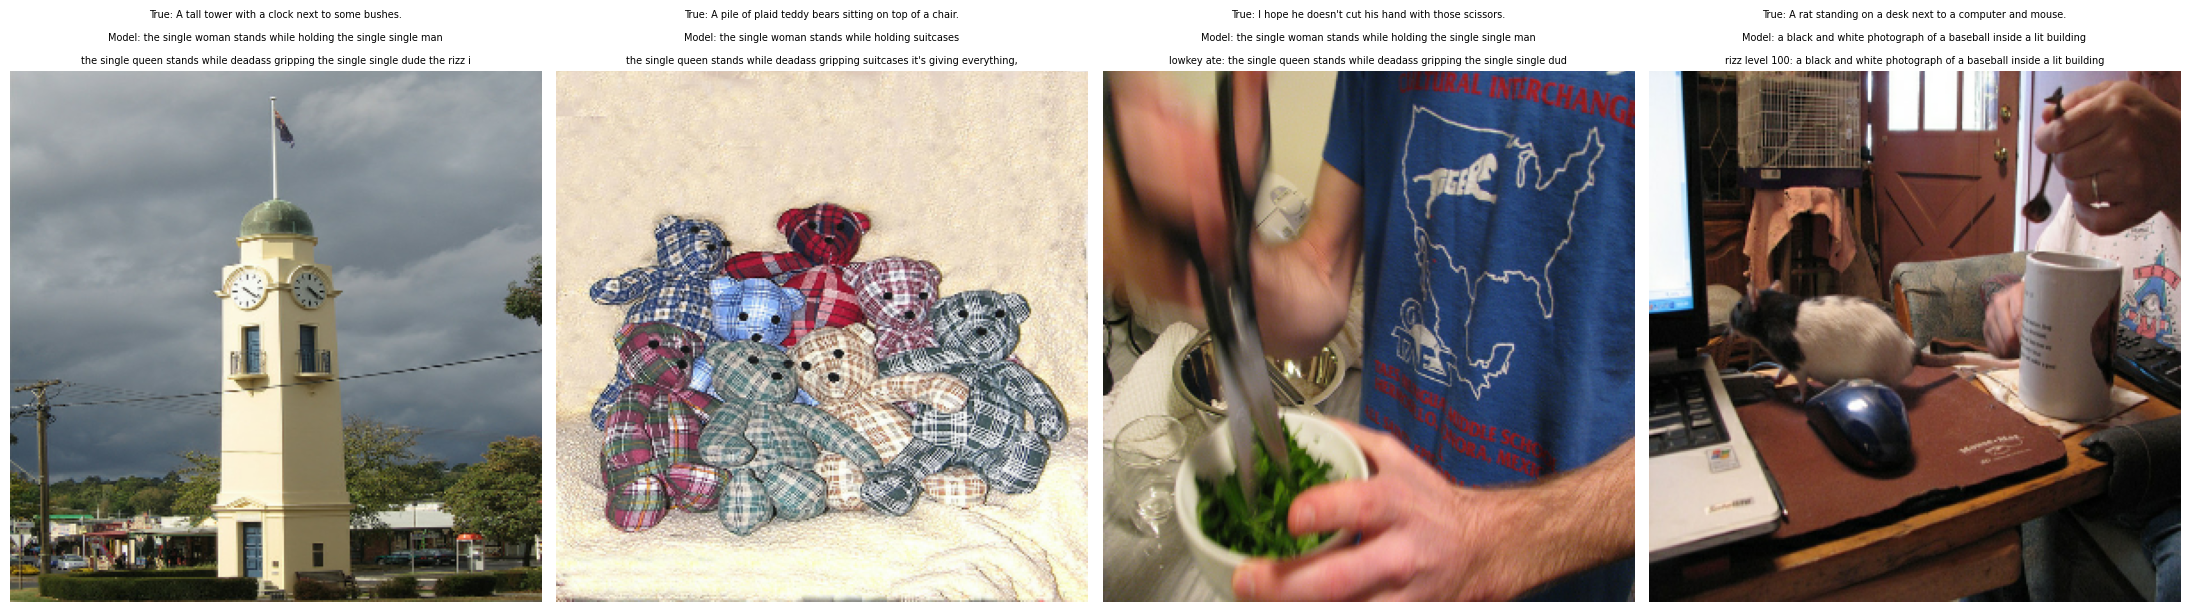

In [17]:
f, axes = plt.subplots(1, 4, figsize=(22, 6))

for idx, data in enumerate(trainds.take(4)):
    raw_img  = data["image_tensor"].numpy()
    true_cap = data["caption"].numpy().decode("utf-8").replace("<start> ", "").replace(" <end>", "")

    img_tensor, pred_cap = predict_caption(raw_img)
    genzcap = genz_rewrite(pred_cap)

    axes[idx].imshow(raw_img)
    axes[idx].axis("off")
    title = (
        f"True: {true_cap[:60]}\n"
        f"\nModel: {pred_cap}\n"
        f"\n{genzcap[:80]}"
    )
    axes[idx].set_title(title, fontsize=7, wrap=True)

plt.tight_layout()
plt.show()

## 11. Caption trial

Test image lets goooooo

In [22]:
# Example 1
# File picker
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print("Uploaded:", IMAGE_PATH)

Saving cat.jpg to cat.jpg
Uploaded: cat.jpg


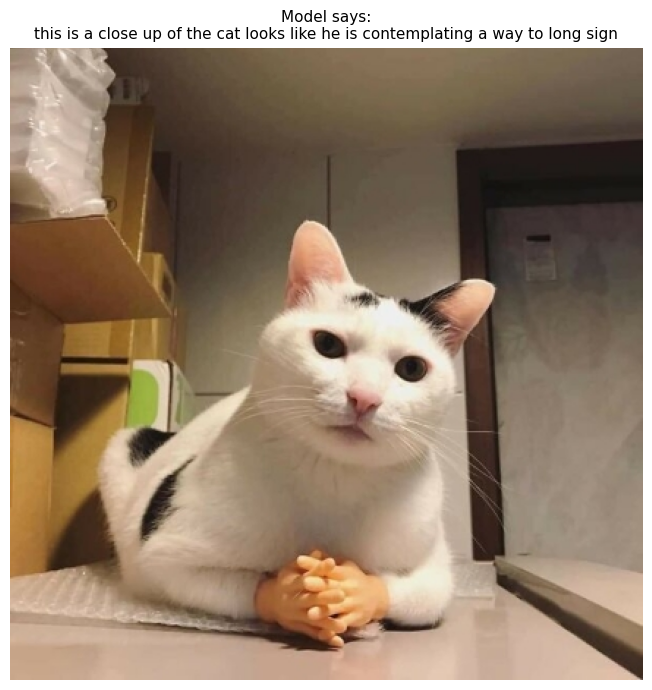

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Normal caption :  this is a close up of the cat looks like he is contemplating a way to long sign
GenZ caption   :  skibidi alert: this is a close up of the car looks like he is contemplating a way to long sign it's giving everything, everything
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [129]:
img_tensor, normal_cap = predict_caption(IMAGE_PATH)
genzcap = genz_rewrite(normal_cap)

# Display
raw = Image.open(IMAGE_PATH)
plt.figure(figsize=(7, 7))
plt.imshow(raw)
plt.axis("off")
plt.title(f"Model says:\n{normal_cap}", fontsize=11)
plt.tight_layout()
plt.show()

print("━" * 60)
print("Normal caption : ", normal_cap)
print("GenZ caption   : ", genzcap)
print("━" * 60)


In [130]:
# Example 2
# File picker
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print("Uploaded:", IMAGE_PATH)


Saving salman pain.jpg to salman pain.jpg
Uploaded: salman pain.jpg


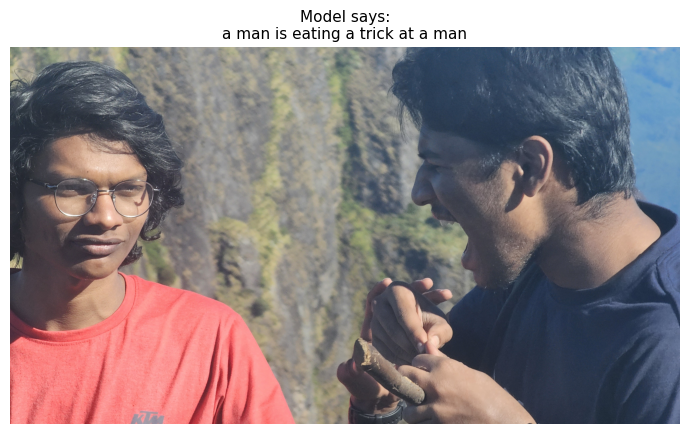

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Normal caption :  a man is eating a trick at a man
GenZ caption   :  fr fr no cap: a dude is going full feral on a trick at a dude that's lowkey bussin ngl
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [186]:
img_tensor, normal_cap = predict_caption(IMAGE_PATH)
genzcap = genz_rewrite(normal_cap)

# Display
raw = Image.open(IMAGE_PATH)
plt.figure(figsize=(7, 7))
plt.imshow(raw)
plt.axis("off")
plt.title(f"Model says:\n{normal_cap}", fontsize=11)
plt.tight_layout()
plt.show()

print("━" * 60)
print("Normal caption : ", normal_cap)
print("GenZ caption   : ", genzcap)
print("━" * 60)


In [187]:
# Example 3
# File picker
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print("Uploaded:", IMAGE_PATH)


Saving 20250107_091502.jpg to 20250107_091502.jpg
Uploaded: 20250107_091502.jpg


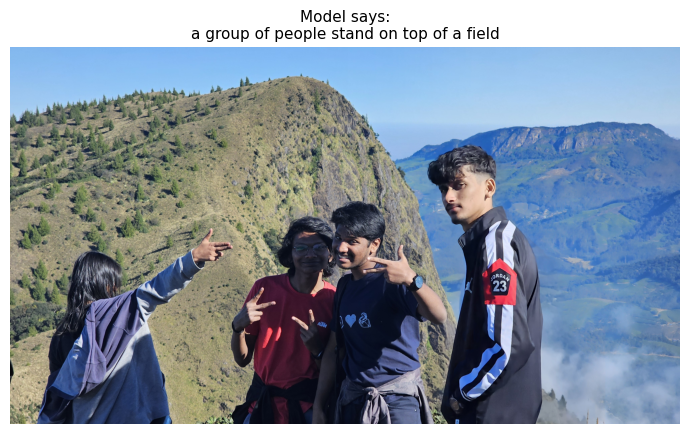

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Normal caption :  a group of people stand on top of a field
GenZ caption   :  rizz level 100: a group of the homies stand on top of a the open sigma field the aura is immac
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [213]:
img_tensor, normal_cap = predict_caption(IMAGE_PATH)
genzcap = genz_rewrite(normal_cap)

# Display
raw = Image.open(IMAGE_PATH)
plt.figure(figsize=(7, 7))
plt.imshow(raw)
plt.axis("off")
plt.title(f"Model says:\n{normal_cap}", fontsize=11)
plt.tight_layout()
plt.show()

print("━" * 60)
print("Normal caption : ", normal_cap)
print("GenZ caption   : ", genzcap)
print("━" * 60)


In [218]:
# Example 4
# File picker
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print("Uploaded:", IMAGE_PATH)


Saving banana man 😎.jpeg to banana man 😎.jpeg
Uploaded: banana man 😎.jpeg


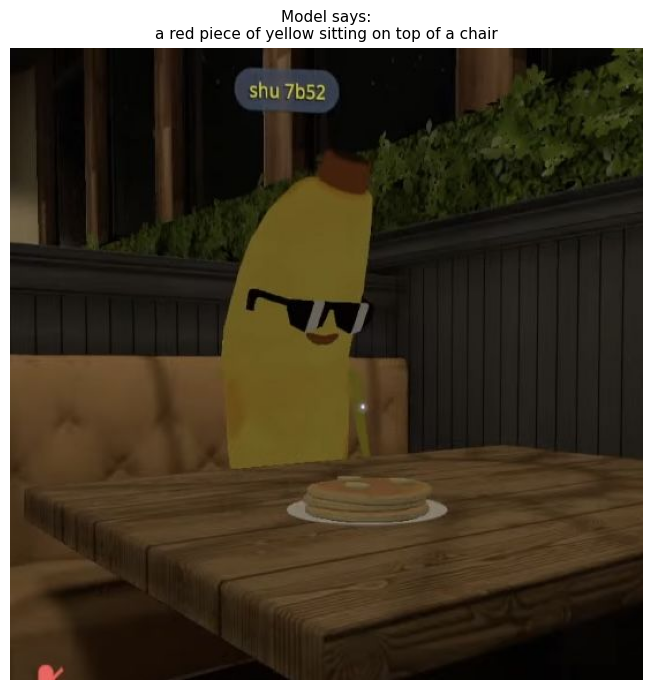

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Normal caption :  a red piece of yellow sitting on top of a chair
GenZ caption   :  core memory unlocked: a red piece of yellow vibing on top of a chair living rent free in my head
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [237]:
img_tensor, normal_cap = predict_caption(IMAGE_PATH)
genzcap = genz_rewrite(normal_cap)

# Display
raw = Image.open(IMAGE_PATH)
plt.figure(figsize=(7, 7))
plt.imshow(raw)
plt.axis("off")
plt.title(f"Model says:\n{normal_cap}", fontsize=11)
plt.tight_layout()
plt.show()

print("━" * 60)
print("Normal caption : ", normal_cap)
print("GenZ caption   : ", genzcap)
print("━" * 60)


## 12. Generate multiple captions (for variety)

Because we sample from the top-K distribution, running the model several times gives different captions for the same image.

In [238]:
print(f"5 captions for: {IMAGE_PATH}\n")
for i in range(5):
    _, cap = predict_caption(IMAGE_PATH)
    genz  = genz_rewrite(cap)
    print(f"[{i+1}]{cap}")
    print(f"{genz}")
    print()

5 captions for: banana man 😎.jpeg

[1]a red piece of cake sits on top of a ledge
bro is actually a red piece of cake sits on top of a ledge the rizz is unreal fr

[2]a red piece of white flowers next to a man sitting
core memory unlocked: a red piece of white flowers posted up next to a dude vibing based and redpilled (jk)

[3]a red piece of yellow flowers next to a street chair
ohio moment: a red piece of yellow flowers posted up next to a street chair based and redpilled (jk)

[4]a red piece of cake on a pole by side
core memory unlocked: a red piece of cake on a pole by side

[5]a yellow fire hydrant sitting below a chair
skibidi alert: a yellow fire hydrant vibing below a chair



## 13. (Optional) Save & reload the model

In [112]:
# Save
#image_caption_train_model.save("/content/caption_model.keras")
#print("Model saved to /content/caption_model.keras")

# To reload later:
loaded_model = keras.models.load_model("/content/caption_model.keras",
                                         custom_objects={"loss_function": loss_function})

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Send us an image for demo please

In [ ]:
# Demo
# File picker
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print("Uploaded:", IMAGE_PATH)


In [ ]:
img_tensor, normal_cap = predict_caption(IMAGE_PATH)
genzcap = genz_rewrite(normal_cap)

# Display
raw = Image.open(IMAGE_PATH)
plt.figure(figsize=(7, 7))
plt.imshow(raw)
plt.axis("off")
plt.title(f"Model says:\n{normal_cap}", fontsize=11)
plt.tight_layout()
plt.show()

print("━" * 60)
print("Normal caption : ", normal_cap)
print("GenZ caption   : ", genzcap)
print("━" * 60)
